# Tutorial 5: Selecting the number of topics

One of the key decisions when running mTopic is choosing the number of topics *K*. mTopic cannot infer *K* automatically — it must be specified before training begins.

The standard approach is to train the model across several values of *K* and evaluate which best captures the underlying structure of your data. We recommend trying *K* = 20, 30, and 50 as a starting point of data exploration. 

This tutorial introduces an automatic workflow for selecting the optimal number of topics using held-out log-likelihood and cross-validation.

---

Throughout this tutorial, we use the Human Tonsil dataset. A few things to keep in mind before you begin:

The input object must contain raw counts. Preprocessing is applied internally during cross-validation, separately for each train/test split — do not normalize or transform the data beforehand.

In [1]:
import numpy as np
import muon as mu
import mtopic

! wget -O Human_Tonsil_RNA_Protein_filtered.h5mu \
  "https://zenodo.org/records/15471869/files/Human_Tonsil_RNA_Protein_filtered.h5mu?download=1"

mdata = mu.read_h5mu("Human_Tonsil_RNA_Protein_filtered.h5mu")
mdata

/mnt/Work/prutkowski/miniconda3/envs/mt5/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


--2026-03-27 19:24:47--  https://zenodo.org/records/15471869/files/Human_Tonsil_RNA_Protein_filtered.h5mu?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.98.114, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16108621 (15M) [application/octet-stream]
Saving to: ‘Human_Tonsil_RNA_Protein_filtered.h5mu’

Human_Tonsil_RNA_Pr 100%[===================>]  15.36M  34.7MB/s    in 0.4s    

2026-03-27 19:24:48 (34.7 MB/s) - ‘Human_Tonsil_RNA_Protein_filtered.h5mu’ saved [16108621/16108621]



MuData object with n_obs × n_vars = 4194 × 5027
  obs:	'in_tissue'
  var:	'gene_ids', 'feature_types', 'genome', 'isotype_control', 'pattern', 'read', 'secondary_name', 'sequence', 'n_counts'
  obsm:	'coords'
  2 modalities
    rna:	4194 x 5000
      obs:	'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'isotype_control', 'pattern', 'read', 'secondary_name', 'sequence', 'n_counts'
    prot:	4194 x 27
      obs:	'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'isotype_control', 'pattern', 'read', 'secondary_name', 'sequence', 'n_counts'

## Running cross-validation

You can run cross-validation to estimate the number of topics with `mtopic.pp.estimate_topic_number`. The cells are randomly split into `n_folds` folds. For each fold, the model is trained on the remaining folds, and the learned topic structure is used to characterise the held-out cells. The quality of this characterisation is measured as a log-likelihood — how probable the held-out data is under the model. This is repeated for every value of *K* in the provided range.

Results are stored directly in `mdata`: per-fold scores in `mdata.uns["CV_results"]` and fold assignments in `mdata.obs["CV_split"]`.

In [2]:
mtopic.pp.estimate_topic_number(mdata, n_folds=3, n_iter=20, n_jobs=100, is_spatial=True)

mdata

[CV 1/3]
  K=5	LL=-152202235.27	t=50.3s
  K=20	LL=-151617576.75	t=33.1s
  K=40	LL=-151520412.50	t=48.2s
  K=60	LL=-151474374.17	t=53.7s
  K=80	LL=-151464746.43	t=59.2s
  K=100	LL=-151426238.39	t=62.5s
[CV 2/3]
  K=5	LL=-152166742.90	t=28.5s
  K=20	LL=-151574786.60	t=30.4s
  K=40	LL=-151460624.79	t=45.7s
  K=60	LL=-151444840.22	t=49.2s
  K=80	LL=-151410228.72	t=54.0s
  K=100	LL=-151381610.96	t=61.1s
[CV 3/3]
  K=5	LL=-152068825.76	t=27.2s
  K=20	LL=-151472417.41	t=28.8s
  K=40	LL=-151384174.67	t=44.1s
  K=60	LL=-151342015.22	t=50.3s
  K=80	LL=-151311830.46	t=54.8s
  K=100	LL=-151277736.02	t=62.8s


MuData object with n_obs × n_vars = 4194 × 5027
  obs:	'in_tissue', 'CV_split'
  var:	'gene_ids', 'feature_types', 'genome', 'isotype_control', 'pattern', 'read', 'secondary_name', 'sequence', 'n_counts'
  uns:	'CV_results'
  obsm:	'coords'
  2 modalities
    rna:	4194 x 5000
      obs:	'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'isotype_control', 'pattern', 'read', 'secondary_name', 'sequence', 'n_counts'
    prot:	4194 x 27
      obs:	'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'isotype_control', 'pattern', 'read', 'secondary_name', 'sequence', 'n_counts'

## Identifying the optimal *K*

Visualize the results with `mtopic.pl.estimate_topic_number`. The held-out log-likelihood increases with *K* across all tested datasets — adding more topics always improves the score to some degree. Because the curve never turns down, we cannot simply pick the maximum. Instead, we look for the point of diminishing returns: the value of *K* beyond which additional topics bring only marginal improvement. To find this point automatically, a rational function is fitted to the curve and the onset of the plateau is identified as the point where the slope drops to 5% of its peak value. The recommended *K* is shown on the plot and stored in `mdata.uns["CV_fit_info"]`. Treat the computed optimal K as a guideline, fell free to select more/fewer topics if you expect more/less granularity.

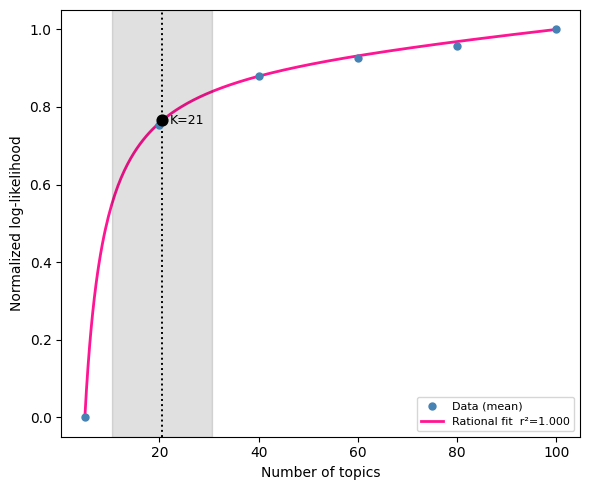

In [3]:
mtopic.pl.estimate_topic_number(mdata)

Here, the optimal number of topics, based on held-out log-likelihood, is 21.

## Conclusions

Cross-validation gives a principled, data-driven estimate of *K*, but it is expensive. Running a full grid of candidate values of *K* with multiple folds means fitting a lot of models per dataset — which can take some time depending on dataset size. The recommended *K* should also be treated as a suggestion rather than a hard answer. For routine use, we recommend a lighter approach: evaluate a small set such as *K* = 20, 30, 50 based on whether the resulting topics make biological sense — do they correspond to known cell types, tissue compartments, or regulatory programmes at the resolution you care about?